# 01 - PCOS Data Audit and EDA

Purpose:

- Load the required PCOS clinical dataset.
- Clean the raw workbook into an analysis-ready table.
- Audit missingness, class balance, outliers, and silently coerced values.
- Save a processed CSV for later notebooks.

Run this notebook first.


In [1]:
from pathlib import Path
import re
import json
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "_read_extract"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"

for folder in [RAW_DIR, OUTPUT_DIR, FIGURE_DIR, MODEL_DIR, METRIC_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ZIP_PATH = PROJECT_ROOT / "OneDrive_1_5-11-2026.zip"
PCOS_XLSX = RAW_DIR / "(Main_Dataset)_PCOS_data_without_infertility.xlsx"
ENDO_CSV = RAW_DIR / "(Supplementary_Dataset)_structured_endometriosis_data.csv"

def ensure_small_datasets_extracted():
    """Extract only the tabular datasets if they are not already available."""
    if PCOS_XLSX.exists() and ENDO_CSV.exists():
        return
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Cannot find {ZIP_PATH}")
    targets = {
        "(Main_Dataset)_PCOS_data_without_infertility.xlsx": PCOS_XLSX,
        "(Supplementary_Dataset)_structured_endometriosis_data.csv": ENDO_CSV,
    }
    with zipfile.ZipFile(ZIP_PATH) as zf:
        for member, destination in targets.items():
            if not destination.exists():
                with zf.open(member) as src, open(destination, "wb") as dst:
                    dst.write(src.read())

ensure_small_datasets_extracted()

def clean_column_name(name):
    name = str(name).strip().lower()
    name = name.replace("β", "beta")
    name = name.replace("marraige", "marriage")
    name = name.replace("bp _", "bp ")
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name

# Columns we never want to keep, even though they parse as numeric.
# - sl_no / patient_file_no: identifiers, no clinical signal.
# - blood_group: stored as ordinal codes (11-18) which has no meaningful order.
# - marriage_status_yrs: clinically sensitive and a poor proxy for anything
#   diagnostic; the plan flags it as unsuitable for screening.
DROP_COLUMNS = ["sl_no", "patient_file_no", "blood_group", "marriage_status_yrs"]

def load_pcos_raw():
    df = pd.read_excel(PCOS_XLSX, sheet_name="Full_new", engine="openpyxl")
    df = df.dropna(how="all").copy()
    df.columns = [clean_column_name(c) for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()].copy()
    return df

def clean_pcos_dataframe(df):
    df = df.copy()

    # Track silently-coerced non-numeric cells so the audit can flag them.
    coercion_report = {}
    for col in df.columns:
        before_non_null = df[col].notna().sum()
        coerced = pd.to_numeric(df[col], errors="coerce")
        new_nan = coerced.isna().sum() - df[col].isna().sum()
        if new_nan > 0:
            offending = df.loc[df[col].notna() & coerced.isna(), col].astype(str).unique().tolist()
            coercion_report[col] = {"coerced_to_nan": int(new_nan), "examples": offending[:5]}
        df[col] = coerced

    drop_now = [c for c in DROP_COLUMNS if c in df.columns]
    df = df.drop(columns=drop_now)

    if "pcos_y_n" not in df.columns:
        raise ValueError("Expected target column 'pcos_y_n' after cleaning column names.")

    df = df[df["pcos_y_n"].isin([0, 1])].copy()
    df["pcos_y_n"] = df["pcos_y_n"].astype(int)

    # Kaggle-style encoding uses 2 for regular and 4/5 for irregular cycles.
    if "cycle_r_i" in df.columns:
        df["cycle_irregular_flag"] = np.where(
            df["cycle_r_i"].isna(),
            np.nan,
            np.where(df["cycle_r_i"] >= 4, 1, 0),
        )

    # Conservative caps for visibly impossible or model-dominating outliers.
    caps = {
        "fsh_miu_ml": (0, 100),
        "lh_miu_ml": (0, 200),
        "fsh_lh": (0, 50),
        "vit_d3_ng_ml": (0, 150),
        "prg_ng_ml": (0, 50),
    }
    for col, (low, high) in caps.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=low, upper=high)

    df.attrs["coercion_report"] = coercion_report
    df.attrs["dropped_columns"] = drop_now
    return df

pcos_raw = load_pcos_raw()
pcos = clean_pcos_dataframe(pcos_raw)
print("PCOS shape:", pcos.shape)
print("Dropped columns:", pcos.attrs["dropped_columns"])
if pcos.attrs["coercion_report"]:
    print("Non-numeric values coerced to NaN:")
    for col, info in pcos.attrs["coercion_report"].items():
        print(f"  {col}: {info['coerced_to_nan']} cell(s); examples={info['examples']}")
print(pcos["pcos_y_n"].value_counts().sort_index())


PCOS shape: (541, 41)
Dropped columns: ['sl_no', 'patient_file_no', 'blood_group', 'marriage_status_yrs']
Non-numeric values coerced to NaN:
  ii_beta_hcg_miu_ml: 1 cell(s); examples=['1.99.']
  amh_ng_ml: 1 cell(s); examples=['a']
pcos_y_n
0    364
1    177
Name: count, dtype: int64


## Save Processed Dataset


In [2]:
processed_path = OUTPUT_DIR / "pcos_cleaned.csv"
pcos.to_csv(processed_path, index=False)
print("Saved:", processed_path)
pcos.head()


Saved: C:\Users\kex03\Downloads\biohackathon\outputs\pcos_cleaned.csv


,pcos_y_n,age_yrs,weight_kg,height_cm,bmi,pulse_rate_bpm,rr_breaths_min,hb_g_dl,cycle_r_i,cycle_length_days,...,fast_food_y_n,reg_exercise_y_n,bp_systolic_mmhg,bp_diastolic_mmhg,follicle_no_l,follicle_no_r,avg_f_size_l_mm,avg_f_size_r_mm,endometrium_mm,cycle_irregular_flag
0,0,28,44.6,152.0,19.304017,78,22,10.48,2,5,...,1.0,0,110,80,3,3,18.0,18.0,8.5,0.0
1,0,36,65.0,161.5,24.921163,74,20,11.70,2,5,...,0.0,0,120,70,3,5,15.0,14.0,3.7,0.0
2,1,33,68.8,165.0,25.270891,72,18,11.80,2,5,...,1.0,0,120,80,13,15,18.0,20.0,10.0,0.0
3,0,37,65.0,148.0,29.674945,72,20,12.00,2,5,...,0.0,0,120,70,2,2,15.0,14.0,7.5,0.0
4,0,25,52.0,161.0,20.060954,72,18,10.00,2,5,...,0.0,0,120,80,3,4,16.0,14.0,7.0,0.0


## Column Audit


In [3]:
audit = pd.DataFrame({
    "column": pcos.columns,
    "dtype": [str(pcos[c].dtype) for c in pcos.columns],
    "missing": [pcos[c].isna().sum() for c in pcos.columns],
    "missing_pct": [pcos[c].isna().mean() for c in pcos.columns],
    "n_unique": [pcos[c].nunique(dropna=True) for c in pcos.columns],
})
audit.to_csv(METRIC_DIR / "pcos_column_audit.csv", index=False)
audit


,column,dtype,missing,missing_pct,n_unique
0,pcos_y_n,int64,0,0.000000,2
1,age_yrs,int64,0,0.000000,29
2,weight_kg,float64,0,0.000000,117
3,height_cm,float64,0,0.000000,50
4,bmi,float64,0,0.000000,387
5,pulse_rate_bpm,int64,0,0.000000,11
6,rr_breaths_min,int64,0,0.000000,8
7,hb_g_dl,float64,0,0.000000,46
8,cycle_r_i,int64,0,0.000000,3
9,cycle_length_days,int64,0,0.000000,12


## Data Quality Issues Coerced During Cleaning

Non-numeric strings in numeric columns silently become NaN. These are logged for the slide-deck data-quality discussion.


In [4]:
coercion_report = pcos.attrs.get("coercion_report", {})
if coercion_report:
    coercion_df = pd.DataFrame([
        {"column": col, "coerced_to_nan": info["coerced_to_nan"], "examples": ", ".join(info["examples"])}
        for col, info in coercion_report.items()
    ])
    coercion_df.to_csv(METRIC_DIR / "pcos_coercion_report.csv", index=False)
    display(coercion_df)
else:
    print("No non-numeric values were coerced.")
print("Columns intentionally dropped:", pcos.attrs.get("dropped_columns", []))


,column,coerced_to_nan,examples
0,ii_beta_hcg_miu_ml,1,1.99.
1,amh_ng_ml,1,a


Columns intentionally dropped: ['sl_no', 'patient_file_no', 'blood_group', 'marriage_status_yrs']


## Class Balance


pcos_y_n
non_pcos    364
pcos        177
Name: count, dtype: int64

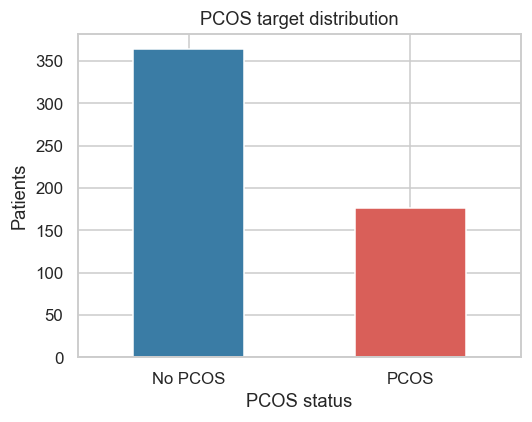

In [5]:
class_counts = pcos["pcos_y_n"].value_counts().sort_index()
display(class_counts.rename({0: "non_pcos", 1: "pcos"}))

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind="bar", ax=ax, color=["#3a7ca5", "#d95f59"])
ax.set_title("PCOS target distribution")
ax.set_xlabel("PCOS status")
ax.set_ylabel("Patients")
ax.set_xticklabels(["No PCOS", "PCOS"], rotation=0)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pcos_class_balance.png", dpi=160)
plt.show()


## Feature Groups


In [6]:
TARGET = "pcos_y_n"

# fast_food_y_n and reg_exercise_y_n are deliberately excluded.
# The plan flags lifestyle proxies as bias-prone and likely to stigmatise patients.
SCREENING_FEATURES = [
    "age_yrs",
    "bmi",
    "cycle_r_i",
    "cycle_irregular_flag",
    "cycle_length_days",
    "weight_gain_y_n",
    "hair_growth_y_n",
    "skin_darkening_y_n",
    "hair_loss_y_n",
    "pimples_y_n",
    "rbs_mg_dl",
    "bp_systolic_mmhg",
    "bp_diastolic_mmhg",
]

ENHANCED_EXTRA_FEATURES = [
    "hb_g_dl",
    "fsh_miu_ml",
    "lh_miu_ml",
    "fsh_lh",
    "tsh_miu_l",
    "amh_ng_ml",
    "prl_ng_ml",
    "vit_d3_ng_ml",
    "prg_ng_ml",
    "follicle_no_l",
    "follicle_no_r",
    "avg_f_size_l_mm",
    "avg_f_size_r_mm",
    "endometrium_mm",
]

def available(features, df):
    return [feature for feature in features if feature in df.columns]

screening_features = available(SCREENING_FEATURES, pcos)
enhanced_features = available(SCREENING_FEATURES + ENHANCED_EXTRA_FEATURES, pcos)

print("Screening features:", screening_features)
print("Enhanced features:", enhanced_features)


Screening features: ['age_yrs', 'bmi', 'cycle_r_i', 'cycle_irregular_flag', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'rbs_mg_dl', 'bp_systolic_mmhg', 'bp_diastolic_mmhg']
Enhanced features: ['age_yrs', 'bmi', 'cycle_r_i', 'cycle_irregular_flag', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'rbs_mg_dl', 'bp_systolic_mmhg', 'bp_diastolic_mmhg', 'hb_g_dl', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh', 'tsh_miu_l', 'amh_ng_ml', 'prl_ng_ml', 'vit_d3_ng_ml', 'prg_ng_ml', 'follicle_no_l', 'follicle_no_r', 'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']


## Summary Statistics by PCOS Status


In [7]:
summary_features = [
    "age_yrs", "bmi", "cycle_r_i", "cycle_irregular_flag", "cycle_length_days",
    "fsh_miu_ml", "lh_miu_ml", "fsh_lh", "amh_ng_ml", "rbs_mg_dl",
    "follicle_no_l", "follicle_no_r", "endometrium_mm",
]
summary_features = available(summary_features, pcos)
summary = pcos.groupby("pcos_y_n")[summary_features].agg(["mean", "median", "std"]).T
summary.to_csv(METRIC_DIR / "pcos_grouped_summary.csv")
summary


pcos_y_n                             0           1
age_yrs              mean    32.065934   30.124294
                     median  32.000000   29.000000
                     std      5.360918    5.292182
bmi                  mean    23.754439   25.481118
                     median  23.618599   25.148605
                     std      3.751457    4.393422
cycle_r_i            mean     2.307692    3.079096
                     median   2.000000    4.000000
                     std      0.722596    1.008184
cycle_irregular_flag mean     0.153846    0.536723
                     median   0.000000    1.000000
                     std      0.361298    0.500064
cycle_length_days    mean     5.126374    4.559322
                     median   5.000000    5.000000
                     std      1.264243    1.821006
fsh_miu_ml           mean     5.581560    5.174593
                     median   5.010000    4.480000
                     std      6.208490    5.744671
lh_miu_ml            mean     2.612676    4.131141
                     median   2.305000    2.220000
                     std      2.103597   15.042957
fsh_lh               mean     4.046015    3.678532
                     median   2.363636    2.036011
                     std      5.646544    6.327031
amh_ng_ml            mean     4.541496    7.844633
                     median   3.200000    5.900000
                     std      4.290579    7.791138
rbs_mg_dl            mean    99.203297  101.136723
                     median  96.000000  100.000000
                     std     15.504283   23.632789
follicle_no_l        mean     4.351648    9.785311
                     median   4.000000   10.000000
                     std      2.814264    4.308977
follicle_no_r        mean     4.637363   10.762712
                     median   4.000000   11.000000
                     std      2.926149    4.165629
endometrium_mm       mean     8.315027    8.806780
                     median   8.300000    8.900000
                     std      2.258606    1.923866

## Symptom Prevalence by PCOS Status


,non_pcos_rate,pcos_rate,absolute_difference
skin_darkening_y_n,0.153846,0.621469,0.467623
weight_gain_y_n,0.228022,0.683616,0.455594
hair_growth_y_n,0.129121,0.570621,0.441501
pimples_y_n,0.390110,0.694915,0.304805
hair_loss_y_n,0.392857,0.576271,0.183414
reg_exercise_y_n,0.228022,0.288136,0.060114


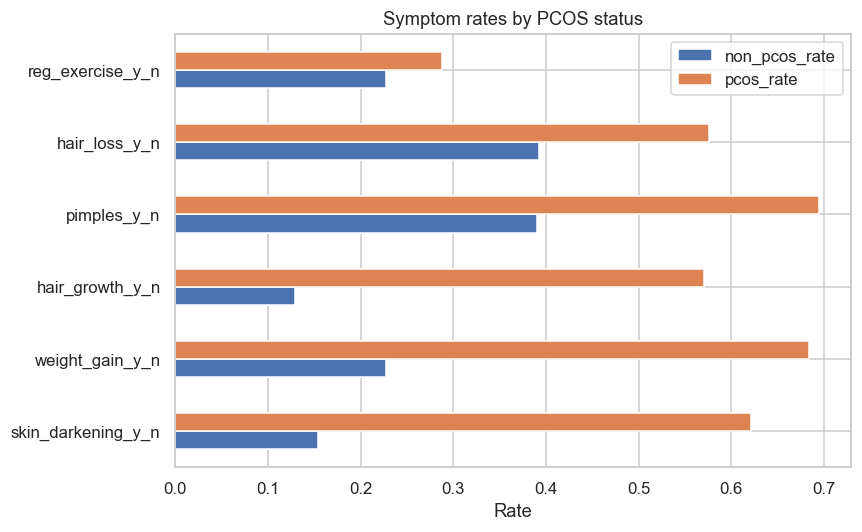

In [8]:
symptom_cols = available([
    "weight_gain_y_n", "hair_growth_y_n", "skin_darkening_y_n",
    "hair_loss_y_n", "pimples_y_n", "reg_exercise_y_n",
], pcos)

symptom_rates = pcos.groupby("pcos_y_n")[symptom_cols].mean().T
symptom_rates.columns = ["non_pcos_rate", "pcos_rate"]
symptom_rates["absolute_difference"] = symptom_rates["pcos_rate"] - symptom_rates["non_pcos_rate"]
symptom_rates = symptom_rates.sort_values("absolute_difference", ascending=False)
symptom_rates.to_csv(METRIC_DIR / "pcos_symptom_rates.csv")
display(symptom_rates)

fig, ax = plt.subplots(figsize=(8, 5))
symptom_rates[["non_pcos_rate", "pcos_rate"]].plot(kind="barh", ax=ax)
ax.set_title("Symptom rates by PCOS status")
ax.set_xlabel("Rate")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pcos_symptom_rates.png", dpi=160)
plt.show()


## Outlier Review


In [9]:
outlier_cols = available([
    "fsh_miu_ml", "lh_miu_ml", "fsh_lh", "vit_d3_ng_ml", "prg_ng_ml",
    "i_beta_hcg_miu_ml", "ii_beta_hcg_miu_ml",
], pcos)

outlier_table = pcos[outlier_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
outlier_table.to_csv(METRIC_DIR / "pcos_outlier_review.csv")
outlier_table


,count,mean,std,min,1%,5%,50%,95%,99%,max
fsh_miu_ml,541.0,5.448412,6.058344,0.210000,1.024000,1.800000,4.850000,9.140000,15.266000,100.00
lh_miu_ml,541.0,3.109475,8.788465,0.020000,0.100000,0.250000,2.300000,7.470000,10.650000,200.00
fsh_lh,541.0,3.925785,5.874504,0.002146,0.435252,0.709234,2.169231,12.761905,31.212308,50.00
vit_d3_ng_ml,541.0,29.336835,14.519778,0.000000,9.280000,12.700000,25.900000,56.200000,72.912000,150.00
prg_ng_ml,541.0,0.546250,2.415029,0.047000,0.150000,0.250000,0.320000,0.880000,1.252000,50.00
i_beta_hcg_miu_ml,541.0,664.549235,3348.920576,1.300000,1.970000,1.990000,20.000000,1134.400000,23790.916000,32460.97
ii_beta_hcg_miu_ml,540.0,238.670480,1605.280485,0.990000,1.947300,1.990000,1.990000,596.401500,3681.340700,25000.00


## Correlation Snapshot


follicle_no_r           0.648327
follicle_no_l           0.603346
skin_darkening_y_n      0.475733
hair_growth_y_n         0.464667
weight_gain_y_n         0.441047
cycle_r_i               0.401644
cycle_irregular_flag    0.400475
fast_food_y_n           0.377933
pimples_y_n             0.286077
amh_ng_ml               0.263863
weight_kg               0.211938
bmi                     0.200176
cycle_length_days       0.178480
hair_loss_y_n           0.172879
age_yrs                 0.168513
waist_inch              0.164598
hip_inch                0.162297
avg_f_size_l_mm         0.132992
endometrium_mm          0.106648
avg_f_size_r_mm         0.097690
Name: pcos_y_n, dtype: float64

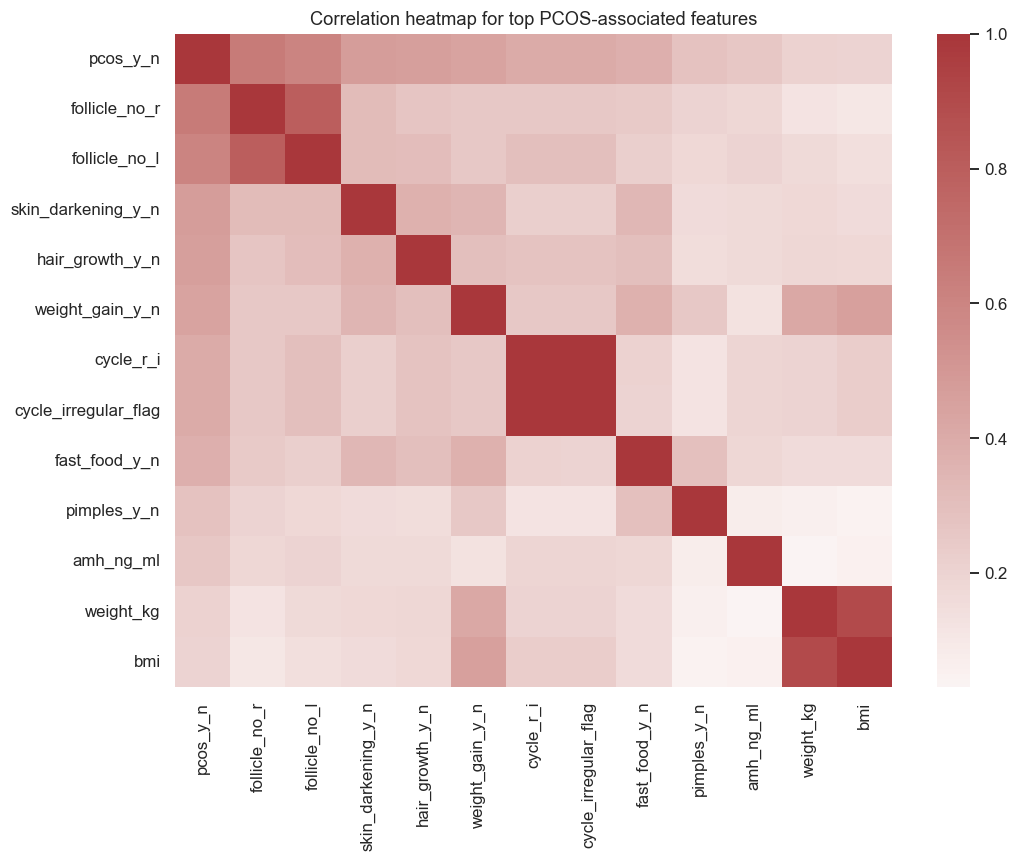

In [10]:
numeric = pcos.select_dtypes(include=[np.number])
top_corr = numeric.corr(numeric_only=True)["pcos_y_n"].drop("pcos_y_n").abs().sort_values(ascending=False).head(20)
display(top_corr)

plot_cols = ["pcos_y_n"] + top_corr.index.tolist()[:12]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric[plot_cols].corr(), cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation heatmap for top PCOS-associated features")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "pcos_correlation_heatmap.png", dpi=160)
plt.show()
